# Notebook 09: LangGraph Multi-Agent Epidemic Workflow

This notebook implements a graph-based multi-agent decision workflow for epidemic response.

## Goals
1. Use explicit graph nodes for metrics, prediction, knowledge retrieval, decisions, and policy activation.
2. Use conditional edges for crisis handling and conflict resolution.
3. Keep design deterministic and auditable for governance-oriented scenarios.
4. Keep everything runnable in Google Colab.

In [11]:
import os
import sys
import subprocess

COLAB = 'google.colab' in sys.modules
if COLAB:
    packages = [
        'mesa==2.3.2',
        'langchain==0.3.27',
        'langchain-community==0.3.27',
        'langchain-openai>=0.3.0',
        'langgraph>=0.2.50',
        'langchain-google-genai>=2.0.0',
        'faiss-cpu==1.11.0.post1',
        'sentence-transformers>=3.0.0',
        'scikit-learn==1.7.1'
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)

print('Environment ready. Colab mode:', COLAB)
print('Groq and Google providers are available via modular LLM config.')

Environment ready. Colab mode: True
Groq and Google providers are available via modular LLM config.


In [12]:
import json
import os
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mesa

from dataclasses import dataclass
from enum import Enum
from typing import Dict, List, Optional, Tuple, TypedDict

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

from langgraph.graph import StateGraph, START, END
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter

try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except Exception:
    ChatGoogleGenerativeAI = None

try:
    from langchain_openai import ChatOpenAI
except Exception:
    ChatOpenAI = None

LLM_PROVIDER = os.getenv('LLM_PROVIDER', 'groq').strip().lower()
LLM_MODEL_ID = os.getenv('LLM_MODEL_ID', 'llama-3.3-70b-versatile').strip()
LLM_API_KEY = os.getenv('LLM_API_KEY', '').strip()
if not LLM_API_KEY:
    LLM_API_KEY = getpass('Enter API key for selected provider (required for LLM mode, blank = fallback mode): ').strip()

LLM_BASE_URLS = {
    'groq': 'https://api.groq.com/openai/v1',
    'openrouter': 'https://openrouter.ai/api/v1',
    'google': None
}
LLM_BASE_URL = LLM_BASE_URLS.get(LLM_PROVIDER)

if LLM_API_KEY:
    os.environ['LLM_API_KEY'] = LLM_API_KEY
    os.environ['OPENAI_API_KEY'] = LLM_API_KEY
    os.environ['OPENROUTER_API_KEY'] = LLM_API_KEY
    os.environ['GOOGLE_API_KEY'] = LLM_API_KEY
    os.environ['GROQ_API_KEY'] = LLM_API_KEY

print('Provider:', LLM_PROVIDER)
print('Model:', LLM_MODEL_ID)
print('LLM enabled:', bool(LLM_API_KEY))

np.random.seed(42)
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 10)

Provider: groq
Model: llama-3.3-70b-versatile
LLM enabled: True


In [13]:
class State:
    SUSCEPTIBLE = 0
    INFECTED_UNTREATED = 1
    HOSPITALIZED = 2
    RECOVERED = 3

class PolicyType(Enum):
    SOCIAL_DISTANCING = 'social_distancing'
    ELECTIVE_SURGERY_BAN = 'elective_surgery_ban'
    MASK_MANDATE = 'mask_mandate'
    SCHOOL_CLOSURE = 'school_closure'
    INTER_HOSPITAL_TRANSFER = 'inter_hospital_transfer'
    CRISIS_STANDARDS = 'crisis_standards'
    RESOURCE_RATIONING = 'resource_rationing'

@dataclass
class Policy:
    policy_type: PolicyType
    active: bool
    effectiveness: float
    implementation_cost: int
    duration_steps: int
    description: str

@dataclass
class Prediction:
    target_metric: str
    current_value: float
    predicted_value: float
    prediction_horizon: int
    confidence: float

class PolicyManager:
    def __init__(self):
        self.active_policies: Dict[PolicyType, Policy] = {}
        self.policy_history: List[Tuple[int, PolicyType, bool]] = []

    def activate_policy(self, policy: Policy, step: int):
        self.active_policies[policy.policy_type] = policy
        self.policy_history.append((step, policy.policy_type, True))

    def get_transmission_modifier(self) -> float:
        modifier = 1.0
        if PolicyType.SOCIAL_DISTANCING in self.active_policies:
            modifier *= 1 - self.active_policies[PolicyType.SOCIAL_DISTANCING].effectiveness
        if PolicyType.MASK_MANDATE in self.active_policies:
            modifier *= 1 - self.active_policies[PolicyType.MASK_MANDATE].effectiveness
        return modifier

    def get_hospital_capacity_modifier(self) -> float:
        modifier = 1.0
        if PolicyType.ELECTIVE_SURGERY_BAN in self.active_policies:
            modifier += self.active_policies[PolicyType.ELECTIVE_SURGERY_BAN].effectiveness
        return modifier

class PredictiveAnalytics:
    def __init__(self, history_window: int = 20):
        self.history_window = history_window

    def predict_hospital_demand(self, historical_data: pd.DataFrame, horizon: int = 5) -> Prediction:
        if len(historical_data) < self.history_window:
            return Prediction('hospital_demand', 0, 0, horizon, 0.5)

        recent_data = historical_data['Total Hospital Occupancy'].tail(self.history_window).values
        x_vals = np.arange(len(recent_data)).reshape(-1, 1)
        model = LinearRegression().fit(x_vals, recent_data)
        future_x = np.arange(len(recent_data), len(recent_data) + horizon).reshape(-1, 1)
        predicted = float(model.predict(future_x)[-1])

        volatility = float(np.std(np.diff(recent_data))) if len(recent_data) > 1 else 0.0
        confidence = max(0.3, 1.0 - volatility / max(1.0, recent_data[-1]))
        return Prediction('hospital_demand', float(recent_data[-1]), predicted, horizon, confidence)

    def predict_infection_peak(self, historical_data: pd.DataFrame) -> Prediction:
        if len(historical_data) < self.history_window:
            return Prediction('infection_peak', 0, 0, 10, 0.5)

        infected_total = (historical_data['Infected (Untreated)'] + historical_data['Hospitalized']).values
        if len(infected_total) < 11:
            current = float(infected_total[-1])
            return Prediction('infection_peak', current, current, 10, 0.4)

        smoothed = savgol_filter(infected_total, 11, 2)
        derivatives = np.diff(smoothed)
        trend = float(np.mean(derivatives[-5:])) if len(derivatives) >= 5 else 0.0
        current = float(infected_total[-1])

        if trend > 0:
            steps_to_peak = max(5, int(current / max(0.1, trend)))
            predicted_peak = current + trend * steps_to_peak
        else:
            steps_to_peak = 0
            predicted_peak = current

        confidence = 0.7 if abs(trend) > 1 else 0.4
        return Prediction('infection_peak', current, float(predicted_peak), steps_to_peak, confidence)

In [14]:
knowledge_docs = {
    'actionable_hospital_protocols.txt': '''
TRIGGER: Hospital occupancy > 80%
ACTIONS:
- ACTIVATE elective_surgery_ban (effectiveness: 0.25, cost: 100)
- INITIATE inter_hospital_transfer (effectiveness: 0.15, cost: 50)

TRIGGER: Hospital occupancy > 90%
ACTIONS:
- ACTIVATE crisis_standards (effectiveness: 0.20, cost: 200)
- IMPLEMENT resource_rationing (effectiveness: 0.10, cost: 150)
''',
    'community_intervention_protocols.txt': '''
TRIGGER: Untreated infected > 100 OR transmission rate > 0.4
ACTIONS:
- IMPLEMENT social_distancing (effectiveness: 0.35, cost: 300)
- ACTIVATE mask_mandate (effectiveness: 0.20, cost: 100)
''',
    'resource_optimization_protocols.txt': '''
TRIGGER: Multiple hospitals > 85% capacity
ACTIONS:
- COORDINATE inter_hospital_transfer (effectiveness: 0.25, cost: 100)

TRIGGER: Predicted ventilator shortage
ACTIONS:
- IMPLEMENT resource_rationing (effectiveness: 0.20, cost: 200)
'''
}

class EnhancedKnowledgeBase:
    def __init__(self, documents_path='knowledge_base_09'):
        os.makedirs(documents_path, exist_ok=True)
        for name, content in knowledge_docs.items():
            with open(os.path.join(documents_path, name), 'w', encoding='utf-8') as f:
                f.write(content)

        splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
        embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

        docs = []
        for name in os.listdir(documents_path):
            if name.endswith('.txt'):
                with open(os.path.join(documents_path, name), 'r', encoding='utf-8') as f:
                    docs.append(Document(page_content=f.read(), metadata={'source': name}))

        chunks = splitter.split_documents(docs)
        self.vectorstore = FAISS.from_documents(chunks, embeddings)

    def search(self, query: str, k: int = 3) -> List[Document]:
        return self.vectorstore.similarity_search(query, k=k)

    def extract_actionable_policies(self, situation: str, k: int = 3) -> List[Policy]:
        mapping = {
            'elective_surgery_ban': (PolicyType.ELECTIVE_SURGERY_BAN, 0.25, 100),
            'social_distancing': (PolicyType.SOCIAL_DISTANCING, 0.35, 300),
            'mask_mandate': (PolicyType.MASK_MANDATE, 0.20, 100),
            'school_closure': (PolicyType.SCHOOL_CLOSURE, 0.20, 350),
            'crisis_standards': (PolicyType.CRISIS_STANDARDS, 0.20, 200),
            'resource_rationing': (PolicyType.RESOURCE_RATIONING, 0.10, 150),
            'inter_hospital_transfer': (PolicyType.INTER_HOSPITAL_TRANSFER, 0.15, 80)
        }

        found: List[Policy] = []
        results = self.search(situation, k=k)
        for result in results:
            content = result.page_content
            for key, values in mapping.items():
                if key in content:
                    ptype, eff, cost = values
                    found.append(Policy(ptype, False, eff, cost, 20, f'KB match: {key}'))
        uniq = {}
        for p in found:
            uniq[p.policy_type] = p
        return list(uniq.values())

kb = EnhancedKnowledgeBase()
analytics = PredictiveAnalytics()
print('Knowledge base and analytics ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Knowledge base and analytics ready.


In [15]:
class PersonAgent(mesa.Agent):
    def __init__(self, unique_id, model, recovery_rate, hospitalized_recovery_rate):
        super().__init__(unique_id, model)
        self.state = State.SUSCEPTIBLE
        self.recovery_rate = recovery_rate
        self.hospitalized_recovery_rate = hospitalized_recovery_rate
        self.hospital_id = None

    def step(self):
        effective_transmission = self.model.base_transmission_rate * self.model.policy_manager.get_transmission_modifier()

        if self.state == State.INFECTED_UNTREATED:
            self.try_to_get_hospitalized()
            self.infect_neighbors(effective_transmission)
            self.try_to_recover(self.recovery_rate)
        elif self.state == State.HOSPITALIZED:
            self.try_to_recover(self.hospitalized_recovery_rate)

        if self.state != State.HOSPITALIZED:
            steps = self.model.grid.get_neighborhood(self.pos, moore=True)
            self.model.grid.move_agent(self, self.random.choice(steps))

    def infect_neighbors(self, transmission_rate):
        for other in self.model.grid.get_cell_list_contents([self.pos]):
            if isinstance(other, PersonAgent) and other.state == State.SUSCEPTIBLE:
                if self.random.random() < transmission_rate:
                    other.state = State.INFECTED_UNTREATED

    def try_to_recover(self, rate):
        if self.random.random() < rate:
            if self.state == State.HOSPITALIZED:
                hospital = next((h for h in self.model.hospitals if h.unique_id == self.hospital_id), None)
                if hospital:
                    hospital.discharge_patient()
                self.hospital_id = None
            self.state = State.RECOVERED

    def try_to_get_hospitalized(self):
        available_hospitals = [h for h in self.model.hospitals if not h.is_full]
        if not available_hospitals:
            return

        closest = min(available_hospitals, key=lambda h: abs(self.pos[0] - h.pos[0]) + abs(self.pos[1] - h.pos[1]))
        if self.pos == closest.pos:
            if closest.admit_patient():
                self.state = State.HOSPITALIZED
                self.hospital_id = closest.unique_id
        else:
            dx = closest.pos[0] - self.pos[0]
            dy = closest.pos[1] - self.pos[1]
            step = (self.pos[0] + int(np.sign(dx)), self.pos[1] + int(np.sign(dy)))
            step = (max(0, min(self.model.grid.width - 1, step[0])), max(0, min(self.model.grid.height - 1, step[1])))
            self.model.grid.move_agent(self, step)

class HospitalAgent(mesa.Agent):
    def __init__(self, unique_id, model, base_capacity=14):
        super().__init__(unique_id, model)
        self.base_capacity = base_capacity
        self.patients = 0

    @property
    def capacity(self):
        return int(self.base_capacity * self.model.policy_manager.get_hospital_capacity_modifier())

    @property
    def is_full(self):
        return self.patients >= self.capacity

    def admit_patient(self):
        if self.is_full:
            return False
        self.patients += 1
        return True

    def discharge_patient(self):
        if self.patients > 0:
            self.patients -= 1

    def step(self):
        return None

class GraphEpidemicModel(mesa.Model):
    def __init__(self, N=700, width=35, height=35, transmission_rate=0.5,
                 recovery_rate=0.04, hospitalized_recovery_rate=0.12,
                 p_initial_infected=0.03, num_hospitals=3, hospital_capacity=14):
        super().__init__()
        self.base_transmission_rate = transmission_rate
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.schedule = mesa.time.RandomActivation(self)
        self.running = True
        self.hospitals = []
        self.policy_manager = PolicyManager()

        hid_start = N + 1000
        for i in range(num_hospitals):
            h = HospitalAgent(hid_start + i, self, hospital_capacity)
            self.hospitals.append(h)
            self.schedule.add(h)
            self.grid.place_agent(h, (self.random.randrange(width), self.random.randrange(height)))

        for i in range(N):
            p = PersonAgent(i, self, recovery_rate, hospitalized_recovery_rate)
            self.schedule.add(p)
            self.grid.place_agent(p, (self.random.randrange(width), self.random.randrange(height)))
            if self.random.random() < p_initial_infected:
                p.state = State.INFECTED_UNTREATED

        self.datacollector = mesa.DataCollector(model_reporters={
            'Susceptible': lambda m: self.count_states(m, PersonAgent, State.SUSCEPTIBLE),
            'Infected (Untreated)': lambda m: self.count_states(m, PersonAgent, State.INFECTED_UNTREATED),
            'Hospitalized': lambda m: self.count_states(m, PersonAgent, State.HOSPITALIZED),
            'Recovered': lambda m: self.count_states(m, PersonAgent, State.RECOVERED),
            'Total Hospital Occupancy': lambda m: sum(h.patients for h in m.hospitals),
            'Hospital Occupancy Rate': lambda m: sum(h.patients for h in m.hospitals) / max(1, sum(h.capacity for h in m.hospitals)),
            'Active Policies': lambda m: len(m.policy_manager.active_policies),
            'Effective Transmission Rate': lambda m: m.base_transmission_rate * m.policy_manager.get_transmission_modifier(),
            'Effective Hospital Capacity': lambda m: sum(h.capacity for h in m.hospitals)
        })

    @staticmethod
    def count_states(model, agent_type, state):
        return sum(1 for a in model.schedule.agents if isinstance(a, agent_type) and a.state == state)

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        if self.count_states(self, PersonAgent, State.INFECTED_UNTREATED) == 0 and self.count_states(self, PersonAgent, State.HOSPITALIZED) == 0:
            self.running = False

print('Simulation classes ready.')

Simulation classes ready.


## LangGraph State and Node Design

The graph uses typed state to track metrics, predictions, candidate policies, activations, and per-step traceability.

In [16]:
class EpidemicGraphState(TypedDict, total=False):
    step: int
    metrics: Dict[str, float]
    predictions: Dict[str, Dict[str, float]]
    candidate_policies: List[str]
    activated_policies: List[str]
    decision_log: List[Dict[str, str]]
    node_trace: List[str]
    interrupt_reason: str

class LangGraphCoordinator:
    def __init__(
        self,
        model: GraphEpidemicModel,
        kb: EnhancedKnowledgeBase,
        analytics: PredictiveAnalytics,
        llm_provider: str = 'groq',
        llm_model_id: str = 'llama-3.3-70b-versatile',
        llm_api_key: str = '',
        llm_base_url: Optional[str] = None,
        temperature: float = 0.1,
        decision_threshold: float = 0.35
    ):
        self.model = model
        self.kb = kb
        self.analytics = analytics
        self.llm_provider = (llm_provider or '').strip().lower()
        self.llm_model_id = (llm_model_id or '').strip()
        self.llm_api_key = (llm_api_key or '').strip()
        self.llm_base_url = llm_base_url
        self.temperature = temperature
        self.decision_threshold = decision_threshold
        self.has_llm = False
        self.policy_text_chain = None
        self.history: List[Dict[str, object]] = []

        llm = None
        if self.llm_api_key:
            llm = self._create_llm()
            self.has_llm = llm is not None

        if self.has_llm and llm is not None:
            prompt = ChatPromptTemplate.from_messages([
                ('system', 'Return strict JSON with key policies as list. Allowed names: social_distancing, mask_mandate, elective_surgery_ban, crisis_standards, inter_hospital_transfer, resource_rationing, school_closure.'),
                ('human', 'Metrics={metrics}, Predictions={predictions}, KB={kb_actions}. JSON only.')
            ])
            self.policy_text_chain = prompt | llm | StrOutputParser()

        self.graph = self._build_graph()

    def _create_llm(self):
        if self.llm_provider == 'groq':
            if ChatOpenAI is None:
                print('Groq provider requested but langchain-openai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatOpenAI(
                    model=self.llm_model_id,
                    api_key=self.llm_api_key,
                    base_url=self.llm_base_url or 'https://api.groq.com/openai/v1',
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'Groq LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        if self.llm_provider == 'openrouter':
            if ChatOpenAI is None:
                print('OpenRouter provider requested but langchain-openai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatOpenAI(
                    model=self.llm_model_id,
                    api_key=self.llm_api_key,
                    base_url=self.llm_base_url or 'https://openrouter.ai/api/v1',
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'OpenRouter LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        if self.llm_provider == 'google':
            if ChatGoogleGenerativeAI is None:
                print('Google provider requested but langchain-google-genai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatGoogleGenerativeAI(
                    model=self.llm_model_id,
                    google_api_key=self.llm_api_key,
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'Google LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        print(f'Unsupported provider: {self.llm_provider}. Falling back to rule-based mode.')
        return None

    def _metrics(self) -> Dict[str, float]:
        total_hospitalized = sum(h.patients for h in self.model.hospitals)
        total_capacity = sum(h.capacity for h in self.model.hospitals)
        infected = self.model.count_states(self.model, PersonAgent, State.INFECTED_UNTREATED)
        return {
            'hospital_occupancy_rate': total_hospitalized / max(1, total_capacity),
            'total_hospitalized': total_hospitalized,
            'total_capacity': total_capacity,
            'infected_untreated': infected,
            'effective_transmission_rate': self.model.base_transmission_rate * self.model.policy_manager.get_transmission_modifier()
        }

    def _predictions(self) -> Dict[str, Dict[str, float]]:
        if len(self.model.datacollector.model_vars) < 15:
            return {}
        df = self.model.datacollector.get_model_vars_dataframe()
        hosp = self.analytics.predict_hospital_demand(df)
        peak = self.analytics.predict_infection_peak(df)
        return {'hospital_demand': hosp.__dict__, 'infection_peak': peak.__dict__}

    def _policy_from_name(self, name: str) -> Optional[Policy]:
        mapping = {
            'social_distancing': (PolicyType.SOCIAL_DISTANCING, 0.30, 300),
            'mask_mandate': (PolicyType.MASK_MANDATE, 0.20, 120),
            'elective_surgery_ban': (PolicyType.ELECTIVE_SURGERY_BAN, 0.25, 100),
            'school_closure': (PolicyType.SCHOOL_CLOSURE, 0.20, 350),
            'inter_hospital_transfer': (PolicyType.INTER_HOSPITAL_TRANSFER, 0.10, 80),
            'crisis_standards': (PolicyType.CRISIS_STANDARDS, 0.15, 200),
            'resource_rationing': (PolicyType.RESOURCE_RATIONING, 0.10, 150)
        }
        if name not in mapping:
            return None
        ptype, eff, cost = mapping[name]
        return Policy(ptype, False, eff, cost, 20, f'Graph activation: {name}')

    def _heuristic_policy_selection(self, metrics: Dict[str, float], candidates: List[str]) -> List[str]:
        selected: List[str] = []
        if metrics['hospital_occupancy_rate'] > 0.55:
            selected.extend(['elective_surgery_ban', 'inter_hospital_transfer'])
        if metrics['hospital_occupancy_rate'] > 0.75:
            selected.extend(['crisis_standards', 'resource_rationing'])
        if metrics['infected_untreated'] > 35 or metrics['effective_transmission_rate'] > 0.20:
            selected.extend(['social_distancing', 'mask_mandate'])
        selected.extend(candidates[:3])
        return list(dict.fromkeys(selected))

    def _score_policy(self, metrics: Dict[str, float], policy: Policy) -> float:
        urgency = 0.0
        urgency += 0.5 if metrics['hospital_occupancy_rate'] > 0.60 else 0.0
        urgency += 0.3 if metrics['infected_untreated'] > 40 else 0.0
        urgency += 0.2 if metrics['effective_transmission_rate'] > 0.20 else 0.0
        return min(1.0, urgency * 0.5 + policy.effectiveness * 0.3 + (1 / (1 + policy.implementation_cost / 100)) * 0.2)

    def _activate_policy_set(self, state: EpidemicGraphState, policy_names: List[str], force: bool = False) -> EpidemicGraphState:
        metrics = state['metrics']
        activated = list(state.get('activated_policies', []))
        logs = state.get('decision_log', [])

        for name in policy_names:
            policy = self._policy_from_name(name)
            if policy is None:
                continue
            if policy.policy_type in self.model.policy_manager.active_policies:
                continue

            score = 1.0 if force else self._score_policy(metrics, policy)
            if force or score >= self.decision_threshold:
                self.model.policy_manager.activate_policy(policy, state['step'])
                activated.append(name)
                logs.append({
                    'step': str(state['step']),
                    'policy': name,
                    'confidence': 'force' if force else f'{score:.2f}'
                })

        state['activated_policies'] = list(dict.fromkeys(activated))
        state['decision_log'] = logs
        return state

    def node_fetch_metrics(self, state: EpidemicGraphState) -> EpidemicGraphState:
        state['metrics'] = self._metrics()
        state['node_trace'] = state.get('node_trace', []) + ['fetch_metrics']
        return state

    def node_predict(self, state: EpidemicGraphState) -> EpidemicGraphState:
        state['predictions'] = self._predictions()
        state['node_trace'] = state.get('node_trace', []) + ['predict']
        return state

    def node_query_kb(self, state: EpidemicGraphState) -> EpidemicGraphState:
        metrics = state['metrics']
        situation = f"Hospital occupancy {metrics['hospital_occupancy_rate']:.1%}. Untreated infected {metrics['infected_untreated']}."
        candidates = self.kb.extract_actionable_policies(situation, k=3)
        state['candidate_policies'] = [p.policy_type.value for p in candidates]
        state['node_trace'] = state.get('node_trace', []) + ['query_kb']
        return state

    def node_decide(self, state: EpidemicGraphState) -> EpidemicGraphState:
        metrics = state['metrics']
        candidates = list(dict.fromkeys(state.get('candidate_policies', [])))
        selected: List[str] = []

        if self.has_llm and self.policy_text_chain is not None:
            raw = self.policy_text_chain.invoke({
                'metrics': json.dumps(metrics),
                'predictions': json.dumps(state.get('predictions', {})),
                'kb_actions': candidates
            })
            try:
                parsed = json.loads(raw)
                selected = [x for x in parsed.get('policies', []) if isinstance(x, str)]
            except Exception:
                selected = []

        if not selected:
            selected = self._heuristic_policy_selection(metrics, candidates)

        if metrics['hospital_occupancy_rate'] > 0.90 and len(self.model.policy_manager.active_policies) == 0:
            selected.extend(['mask_mandate', 'social_distancing', 'elective_surgery_ban'])

        selected = list(dict.fromkeys(selected))
        state['activated_policies'] = []
        state = self._activate_policy_set(state, selected, force=False)
        state['node_trace'] = state.get('node_trace', []) + ['decide']
        return state

    def node_conflict_resolution(self, state: EpidemicGraphState) -> EpidemicGraphState:
        activated = state.get('activated_policies', [])
        if 'school_closure' in activated and 'resource_rationing' in activated:
            activated.remove('school_closure')
            state['decision_log'] = state.get('decision_log', []) + [{
                'step': str(state['step']),
                'policy': 'school_closure_removed',
                'confidence': 'rule'
            }]
        state['activated_policies'] = activated
        state['node_trace'] = state.get('node_trace', []) + ['conflict_resolution']
        return state

    def node_surge_policy(self, state: EpidemicGraphState) -> EpidemicGraphState:
        surge_order = [
            'crisis_standards',
            'resource_rationing',
            'elective_surgery_ban',
            'inter_hospital_transfer',
            'mask_mandate',
            'social_distancing',
            'school_closure'
        ]
        state = self._activate_policy_set(state, surge_order, force=True)
        state['interrupt_reason'] = 'Crisis threshold reached: surge policy activation executed.'
        state['node_trace'] = state.get('node_trace', []) + ['surge_policy']
        return state

    def node_interrupt(self, state: EpidemicGraphState) -> EpidemicGraphState:
        state['interrupt_reason'] = 'Hospital occupancy exceeded 95%; recommend human review.'
        state['node_trace'] = state.get('node_trace', []) + ['interrupt']
        return state

    def route_after_decision(self, state: EpidemicGraphState) -> str:
        if state['metrics']['hospital_occupancy_rate'] > 0.95:
            return 'surge'
        activated = state.get('activated_policies', [])
        if 'school_closure' in activated and 'resource_rationing' in activated:
            return 'conflict'
        return 'end'

    def _build_graph(self):
        builder = StateGraph(EpidemicGraphState)
        builder.add_node('fetch_metrics', self.node_fetch_metrics)
        builder.add_node('predict', self.node_predict)
        builder.add_node('query_kb', self.node_query_kb)
        builder.add_node('decide', self.node_decide)
        builder.add_node('conflict_resolution', self.node_conflict_resolution)
        builder.add_node('surge_policy', self.node_surge_policy)
        builder.add_node('interrupt', self.node_interrupt)

        builder.add_edge(START, 'fetch_metrics')
        builder.add_edge('fetch_metrics', 'predict')
        builder.add_edge('predict', 'query_kb')
        builder.add_edge('query_kb', 'decide')

        builder.add_conditional_edges('decide', self.route_after_decision, {
            'surge': 'surge_policy',
            'conflict': 'conflict_resolution',
            'end': END
        })
        builder.add_edge('conflict_resolution', END)
        builder.add_edge('surge_policy', END)
        builder.add_edge('interrupt', END)

        return builder.compile()

    def run_graph_step(self, step: int) -> Dict[str, object]:
        initial: EpidemicGraphState = {
            'step': step,
            'decision_log': [],
            'node_trace': []
        }
        out = self.graph.invoke(initial)
        self.history.append({
            'step': step,
            'trace': out.get('node_trace', []),
            'activated': out.get('activated_policies', []),
            'interrupt_reason': out.get('interrupt_reason', '')
        })
        return out

print('LangGraph coordinator ready.')

LangGraph coordinator ready.


In [17]:
POPULATION = 900
GRID_WIDTH = 35
GRID_HEIGHT = 35
BASE_TRANSMISSION_RATE = 0.95
RECOVERY_RATE = 0.04
HOSPITALIZED_RECOVERY_RATE = 0.05
INITIAL_INFECTED_P = 0.3
NUM_HOSPITALS = 3
HOSPITAL_CAPACITY = 6
SIMULATION_STEPS = 100
GRAPH_INTERVAL = 1

model = GraphEpidemicModel(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=BASE_TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P,
    num_hospitals=NUM_HOSPITALS,
    hospital_capacity=HOSPITAL_CAPACITY
)

coordinator = LangGraphCoordinator(
    model,
    kb,
    analytics,
    llm_provider=LLM_PROVIDER,
    llm_model_id=LLM_MODEL_ID,
    llm_api_key=LLM_API_KEY,
    llm_base_url=LLM_BASE_URL,
    temperature=0.1,
    decision_threshold=0.35
)
graph_outputs = []

print(f"Runtime LLM mode: {'enabled' if coordinator.has_llm else 'fallback'}")
print(f"Provider: {LLM_PROVIDER} | Model: {LLM_MODEL_ID}")

for step in range(SIMULATION_STEPS):
    if not model.running:
        print(f'Simulation ended early at step {step}.')
        break

    model.step()
    if step % GRAPH_INTERVAL == 0:
        out = coordinator.run_graph_step(step)
        graph_outputs.append(out)

results_df = model.datacollector.get_model_vars_dataframe()
trace_df = pd.DataFrame(coordinator.history) if coordinator.history else pd.DataFrame()

print('Simulation complete.')
print('Graph decision cycles:', len(coordinator.history))
print('Active policies at end:', len(model.policy_manager.active_policies))
if not trace_df.empty:
    print('Latest graph trace:', trace_df.tail(1).to_dict('records')[0])

Runtime LLM mode: enabled
Provider: groq | Model: llama-3.3-70b-versatile
Simulation complete.
Graph decision cycles: 100
Active policies at end: 7
Latest graph trace: {'step': 99, 'trace': ['fetch_metrics', 'predict', 'query_kb', 'decide'], 'activated': [], 'interrupt_reason': ''}


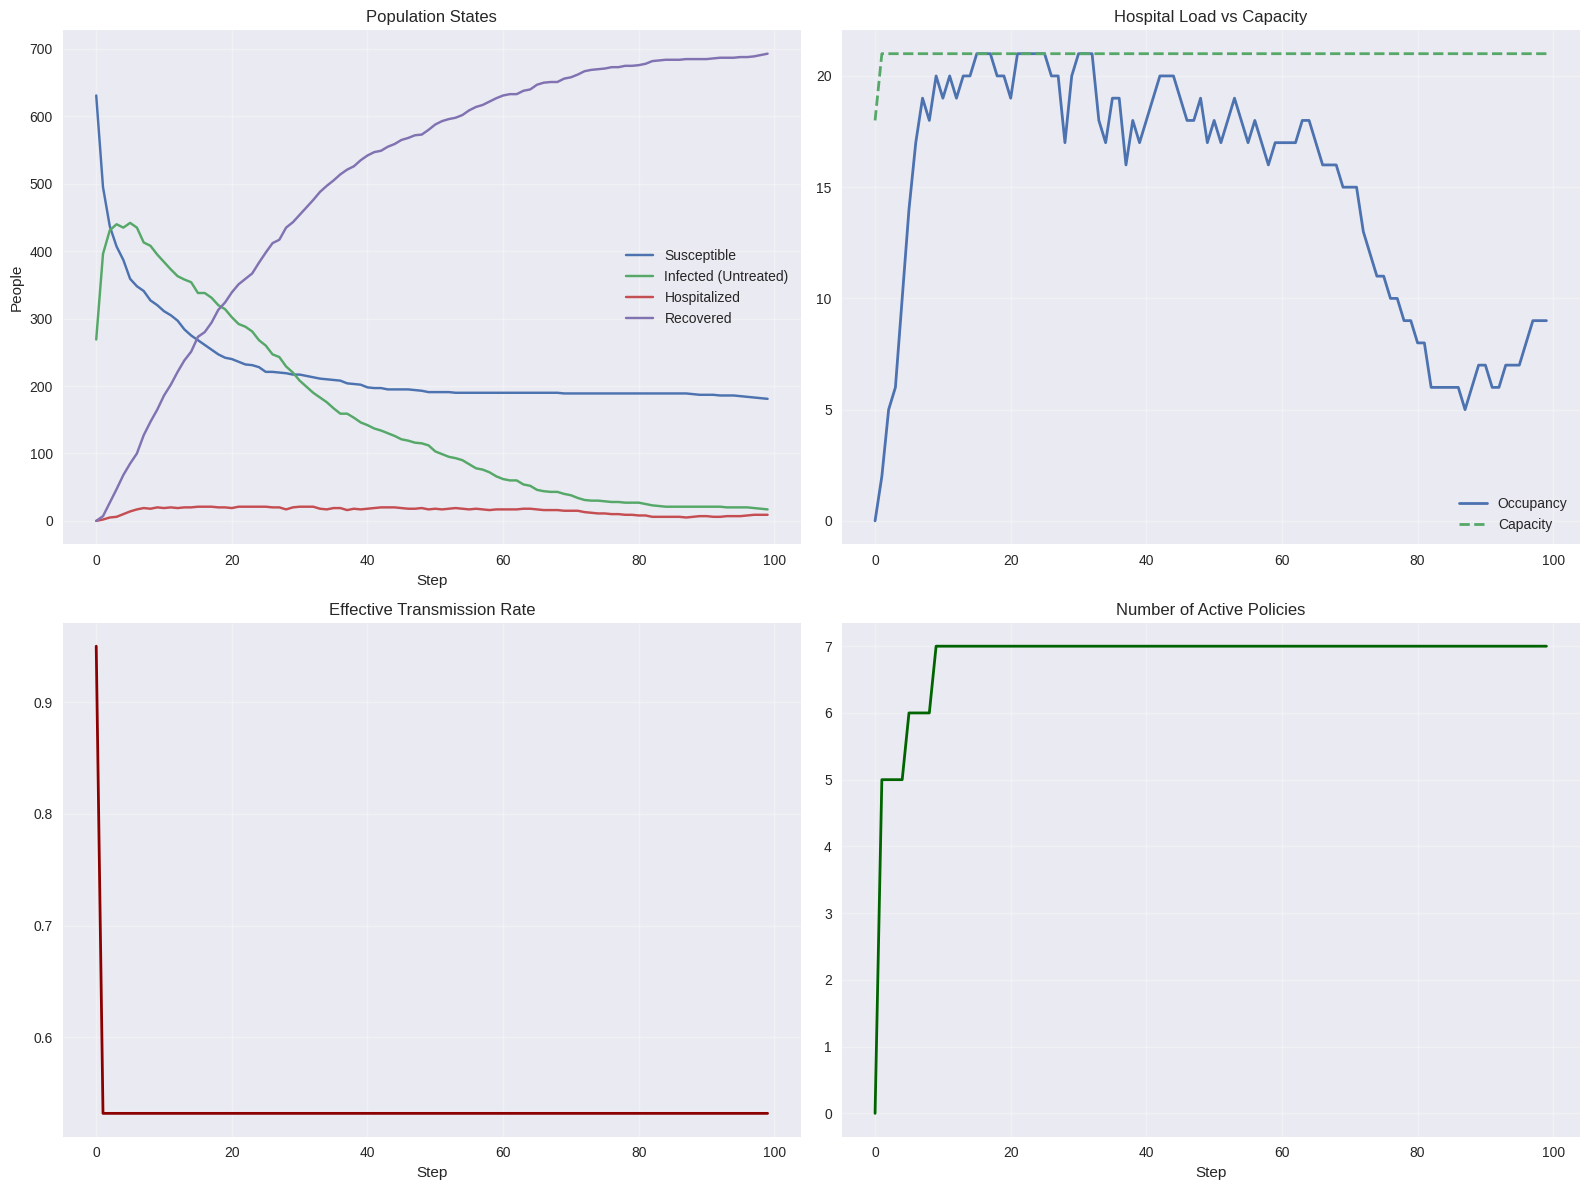

Graph node traces:


,step,trace,activated,interrupt_reason
90,90,"[fetch_metrics, predict, query_kb, decide]",[],
91,91,"[fetch_metrics, predict, query_kb, decide]",[],
92,92,"[fetch_metrics, predict, query_kb, decide]",[],
93,93,"[fetch_metrics, predict, query_kb, decide]",[],
94,94,"[fetch_metrics, predict, query_kb, decide]",[],
95,95,"[fetch_metrics, predict, query_kb, decide]",[],
96,96,"[fetch_metrics, predict, query_kb, decide]",[],
97,97,"[fetch_metrics, predict, query_kb, decide]",[],
98,98,"[fetch_metrics, predict, query_kb, decide]",[],
99,99,"[fetch_metrics, predict, query_kb, decide]",[],


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

results_df[['Susceptible', 'Infected (Untreated)', 'Hospitalized', 'Recovered']].plot(ax=axes[0, 0], title='Population States')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('People')

axes[0, 1].plot(results_df.index, results_df['Total Hospital Occupancy'], label='Occupancy', linewidth=2)
axes[0, 1].plot(results_df.index, results_df['Effective Hospital Capacity'], label='Capacity', linewidth=2, linestyle='--')
axes[0, 1].set_title('Hospital Load vs Capacity')
axes[0, 1].legend()

axes[1, 0].plot(results_df.index, results_df['Effective Transmission Rate'], color='darkred', linewidth=2)
axes[1, 0].set_title('Effective Transmission Rate')
axes[1, 0].set_xlabel('Step')

axes[1, 1].plot(results_df.index, results_df['Active Policies'], color='darkgreen', linewidth=2)
axes[1, 1].set_title('Number of Active Policies')
axes[1, 1].set_xlabel('Step')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if not trace_df.empty:
    print('Graph node traces:')
    display(trace_df.tail(10))
else:
    print('No graph traces recorded in this run.')

## Advantages of LangGraph Design

1. Deterministic control flow: each decision passes through explicit nodes and edges.
2. Better governance: conditional routes (interrupt/conflict) make policy risk handling explicit.
3. Debugging clarity: node trace history explains exactly how each activation was produced.
4. Production readiness: graph patterns map naturally to monitored pipelines.

## Limitations

1. More upfront design overhead than free-form agent orchestration.
2. Graph maintenance can grow complex as routing branches increase.
3. Requires disciplined state schema management for long-term evolution.

## LangChain vs LangGraph (Quick Guidance)

1. Choose LangChain when you want fast experimentation and prompt/tool iteration.
2. Choose LangGraph when you need deterministic execution and stronger auditability.
3. Use both together when prototyping first (LangChain), then hardening workflows (LangGraph).